# Mixed Multimodal Dataset Construction (Balanced)

Creates `mm_*_mixed_balanced_group_test.csv` — balanced mixed dataset where
fraud can come from the transaction side, the image side, or both.

### Design 
| Combo | Label | Meaning |
|---|---|---|
| tab0_img0 | 0 | fully legitimate |
| tab1_img1 | 1 | both suspicious |
| tab1_img0 | 1 | transaction fraud only |
| tab0_img1 | 1 | image fraud only |

**Equal combo counts** — each combo type gets the same n rows.  
Final label is naturally 1:3 — handled during training with pos_weight=3.  
**Source-balanced** — MIDV/FantasyID/FMIDV contribute equally per combo.

## 0 · Imports & paths

In [1]:
import sys, os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR  = PROJECT_ROOT / "notebook" / "results" / "mm_mixed_balanced_construction"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

COMBO_COLOURS = {"tab0_img0":"#4C72B0","tab1_img1":"#C44E52",
                 "tab1_img0":"#DD8452","tab0_img1":"#55A868"}

FILES = [
    "mm_train_mixed_balanced_group_test.csv",
    "mm_val_mixed_balanced_group_test.csv",
    "mm_test_mixed_balanced_group_test.csv",
    "mm_full_mixed_balanced_group_test.csv",
]

print("Data dir:", DATA_DIR)

Data dir: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed


## 1 · Delete old files (run to force rebuild)

In [2]:
# Run this cell to delete existing files and force a fresh rebuild
for f in FILES:
    path = DATA_DIR / f
    if path.exists():
        os.remove(path)
        print(f"Deleted: {f}")
    else:
        print(f"Not found (ok): {f}")

Not found (ok): mm_train_mixed_balanced_group_test.csv
Not found (ok): mm_val_mixed_balanced_group_test.csv
Not found (ok): mm_test_mixed_balanced_group_test.csv
Not found (ok): mm_full_mixed_balanced_group_test.csv


## 2 · Build the balanced mixed dataset

In [3]:
script_path = PROJECT_ROOT / "src" / "build_merged_dataset_mixed_balanced.py"
print("Script exists:", script_path.exists())

all_exist = all((DATA_DIR / f).exists() for f in FILES)

if all_exist:
    print("Files already exist — skipping build. Run cell 1 to rebuild.")
elif not script_path.exists():
    print("ERROR: script not found at:", script_path)
    print("Copy build_merged_dataset_mixed_balanced.py to src/ first.")
else:
    print("Building...")
    import subprocess
    result = subprocess.run(
        [sys.executable, str(script_path)],
        capture_output=True, text=True, cwd=str(PROJECT_ROOT)
    )
    print(result.stdout[-4000:] if result.stdout else "(no output)")
    if result.returncode != 0:
        print("\nERRORS:")
        print(result.stderr[-2000:])
    else:
        print("\nBuild complete.")

Script exists: True
Building...
l-fraud-detection-thesis\data\processed\mm_val_mixed_balanced_group_test.csv
Saved: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\mm_test_mixed_balanced_group_test.csv
Saved: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\mm_full_mixed_balanced_group_test.csv

MM TRAIN BALANCED
Shape: (2652, 32)

Final label distribution:
final_label
1    1989
0     663
Name: count, dtype: int64
  Ratio label-0:label-1 = 1:3.0

Combo type breakdown:
combo_type
tab0_img0    663
tab0_img1    663
tab1_img0    663
tab1_img1    663
Name: count, dtype: int64

Combo type x final_label:
final_label    0    1
combo_type           
tab0_img0    663    0
tab0_img1      0  663
tab1_img0      0  663
tab1_img1      0  663

Source x combo_type:
combo_type          tab0_img0  tab0_img1  tab1_img0  tab1_img1
img_source_dataset                                            
fantasyid                 342        321        321   

## 3 · Load

In [4]:
script_path = PROJECT_ROOT / "src" / "build_merged_dataset_mixed_balanced.py"
print("Script exists:", script_path.exists())
print("Script path:", script_path)

Script exists: True
Script path: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src\build_merged_dataset_mixed_balanced.py


In [5]:
train_df = pd.read_csv(DATA_DIR / "mm_train_mixed_balanced_group_test.csv")
val_df   = pd.read_csv(DATA_DIR / "mm_val_mixed_balanced_group_test.csv")
test_df  = pd.read_csv(DATA_DIR / "mm_test_mixed_balanced_group_test.csv")

print(f"Train: {train_df.shape}")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")
print(f"\nColumns ({len(train_df.columns)}):")
print(train_df.columns.tolist())

Train: (2652, 32)
Val:   (588, 32)
Test:  (492, 32)

Columns (32):
['tab_step', 'tab_type', 'tab_amount', 'tab_nameOrig', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_nameDest', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFraud', 'tab_isFlaggedFraud', 'tab_sample_id', 'tab_split', 'tab_tabular_id', 'tab_final_label', 'img_image_path', 'img_source_dataset', 'img_image_class', 'img_group_key', 'img_doc_type', 'img_source_type', 'img_file_name', 'img_split_source', 'img_original_label', 'img_split', 'img_final_label', 'final_label', 'tab_fraud_label', 'img_fraud_label', 'combo_type', 'split', 'mm_id']


## 4 · Combo type distribution
All four combos should have equal counts in every split.

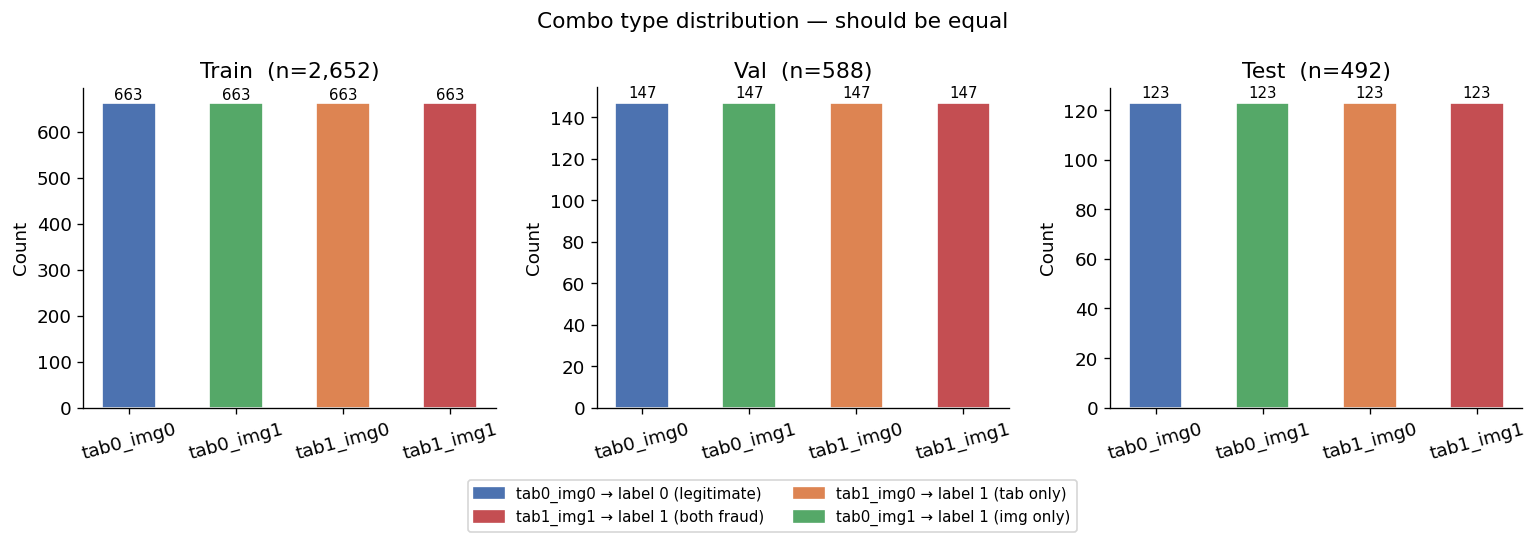


Combo counts per split:
  Train: {'tab0_img0': 663, 'tab0_img1': 663, 'tab1_img0': 663, 'tab1_img1': 663}
  Val: {'tab0_img0': 147, 'tab0_img1': 147, 'tab1_img0': 147, 'tab1_img1': 147}
  Test: {'tab0_img0': 123, 'tab0_img1': 123, 'tab1_img0': 123, 'tab1_img1': 123}


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, df) in zip(axes, [("Train", train_df),
                                   ("Val",   val_df),
                                   ("Test",  test_df)]):
    combo_counts = df["combo_type"].value_counts().sort_index()
    colours_list = [COMBO_COLOURS.get(c,"gray") for c in combo_counts.index]
    bars = ax.bar(combo_counts.index, combo_counts.values,
                  color=colours_list, edgecolor="white", width=0.5)
    for bar, val in zip(bars, combo_counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                str(val), ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{name}  (n={len(df):,})")
    ax.set_ylabel("Count"); ax.tick_params(axis="x", rotation=15)
    ax.spines[["top","right"]].set_visible(False)

legend_elements = [
    Patch(color="#4C72B0", label="tab0_img0 → label 0 (legitimate)"),
    Patch(color="#C44E52", label="tab1_img1 → label 1 (both fraud)"),
    Patch(color="#DD8452", label="tab1_img0 → label 1 (tab only)"),
    Patch(color="#55A868", label="tab0_img1 → label 1 (img only)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5,-0.12), fontsize=9)
fig.suptitle("Combo type distribution", fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "combo_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCombo counts per split:")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name}: {df['combo_type'].value_counts().sort_index().to_dict()}")

## 5 · Label distribution
Expect 1:3 ratio (label-0 : label-1). Handle with pos_weight=3 during training.

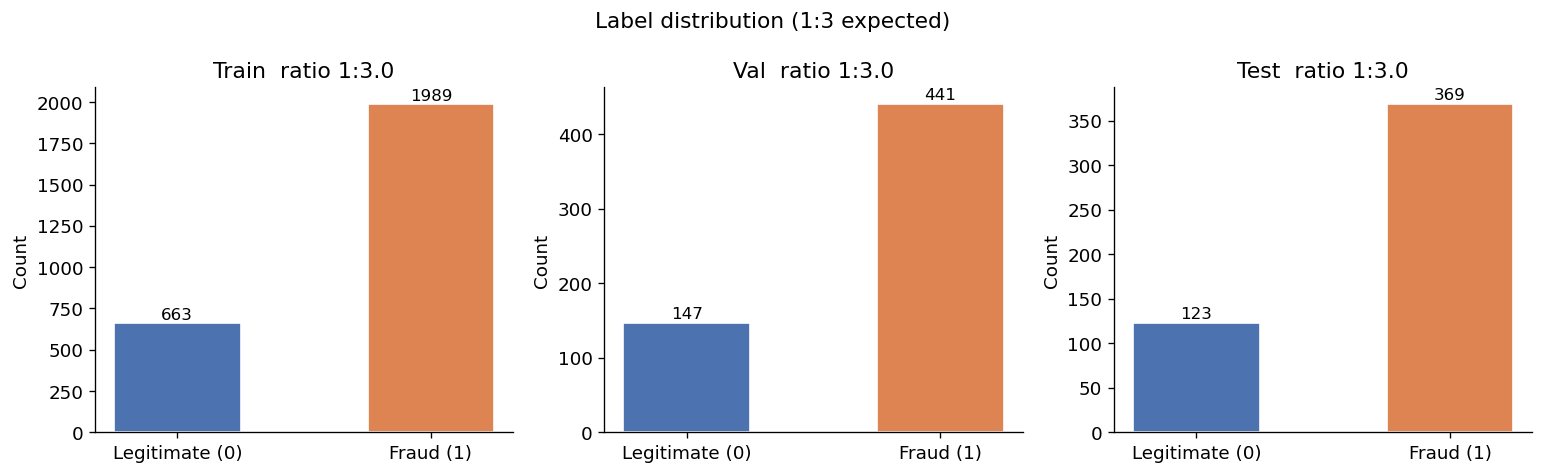

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, df) in zip(axes, [("Train", train_df),
                                   ("Val",   val_df),
                                   ("Test",  test_df)]):
    counts = df["final_label"].value_counts().sort_index()
    bars = ax.bar(["Legitimate (0)","Fraud (1)"], counts.values,
                  color=["#4C72B0","#DD8452"], edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                str(val), ha="center", va="bottom", fontsize=10)
    ratio = counts.get(1,0) / max(counts.get(0,1), 1)
    ax.set_title(f"{name}  ratio 1:{ratio:.1f}")
    ax.set_ylabel("Count"); ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Label distribution (1:3 expected)", fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 · Source balance per combo type
All three sources should contribute equally to each combo.

Source x combo_type (train):


combo_type,tab0_img0,tab0_img1,tab1_img0,tab1_img1,All
img_source_dataset,,,,,
fantasyid,342,321,321,342,1326
fmidv,0,342,0,321,663
midv,321,0,342,0,663
All,663,663,663,663,2652


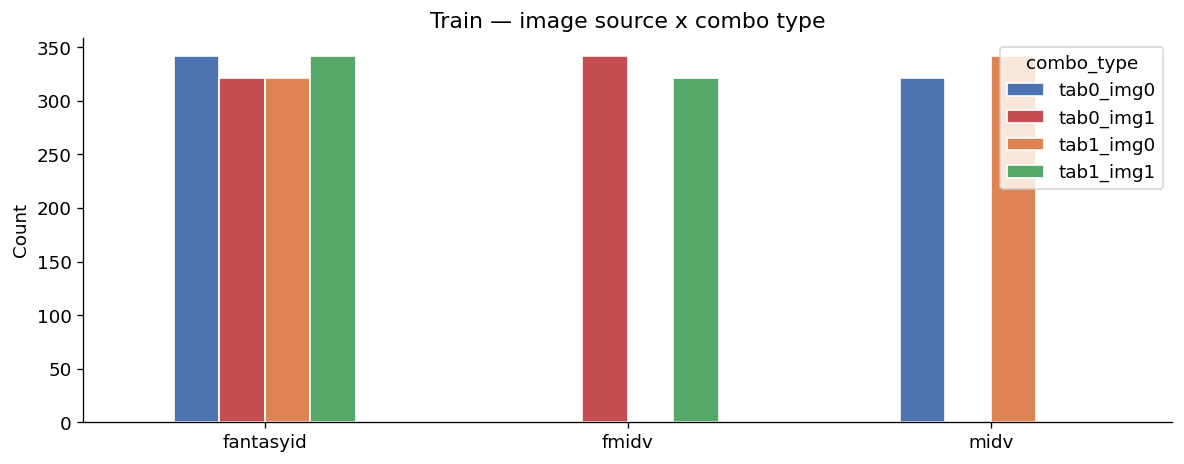

In [8]:
if "img_source_dataset" in train_df.columns:
    print("Source x combo_type (train):")
    display(pd.crosstab(train_df["img_source_dataset"],
                        train_df["combo_type"], margins=True))

    fig, ax = plt.subplots(figsize=(10, 4))
    pd.crosstab(train_df["img_source_dataset"],
                train_df["combo_type"]).plot(
        kind="bar", ax=ax,
        color=list(COMBO_COLOURS.values()), edgecolor="white")
    ax.set_title("Train — image source x combo type")
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
    ax.set_ylabel("Count"); ax.spines[["top","right"]].set_visible(False)
    ax.legend(title="combo_type")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "source_x_combo.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7 · Leakage checks

In [9]:
# Fix NaN leakage first
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    n_null = df["img_image_path"].isna().sum()
    if n_null > 0:
        print(f"Warning: {n_null} null img_image_path in {name}")

train_imgs = set(train_df["img_image_path"].dropna())
val_imgs   = set(val_df["img_image_path"].dropna())
test_imgs  = set(test_df["img_image_path"].dropna())

tv = len(train_imgs & val_imgs)
tt = len(train_imgs & test_imgs)
vt = len(val_imgs   & test_imgs)

print("Image path overlap:")
print(f"  Train ∩ Val:  {tv}  {'⚠️  LEAKAGE' if tv>0 else '✅  clean'}")
print(f"  Train ∩ Test: {tt}  {'⚠️  LEAKAGE' if tt>0 else '✅  clean'}")
print(f"  Val   ∩ Test: {vt}  {'⚠️  LEAKAGE' if vt>0 else '✅  clean'}")

print(f"\nDuplicate mm_ids — train:{train_df['mm_id'].duplicated().sum()} "
      f"val:{val_df['mm_id'].duplicated().sum()} "
      f"test:{test_df['mm_id'].duplicated().sum()}")

Image path overlap:
  Train ∩ Val:  0  ✅  clean
  Train ∩ Test: 0  ✅  clean
  Val   ∩ Test: 0  ✅  clean

Duplicate mm_ids — train:0 val:0 test:0


## 8 · Group key leakage
Image group_keys should not appear across splits.

In [10]:
if "img_group_key" in train_df.columns:
    tg = set(train_df["img_group_key"])
    vg = set(val_df["img_group_key"])
    eg = set(test_df["img_group_key"])
    print(f"Group key overlap:")
    print(f"  Train ∩ Val:  {len(tg & vg)}  {'⚠️' if len(tg & vg)>0 else '✅'}")
    print(f"  Train ∩ Test: {len(tg & eg)}  {'⚠️' if len(tg & eg)>0 else '✅'}")
    print(f"  Val   ∩ Test: {len(vg & eg)}  {'⚠️' if len(vg & eg)>0 else '✅'}")

Group key overlap:
  Train ∩ Val:  0  ✅
  Train ∩ Test: 0  ✅
  Val   ∩ Test: 0  ✅


## 9 · Summary

In [11]:
print("Balanced Mixed Multimodal Dataset Summary")
print("="*55)
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    combos = df["combo_type"].value_counts().sort_index().to_dict()
    ratio  = df["final_label"].value_counts().get(1,0) / max(df["final_label"].value_counts().get(0,1),1)
    print(f"\n{name}: {len(df):,} rows | label ratio 1:{ratio:.1f}")
    print(f"  {combos}")

print("\nFiles:")
for f in FILES:
    print(f"  {f}: {(DATA_DIR/f).exists()}")

Balanced Mixed Multimodal Dataset Summary

Train: 2,652 rows | label ratio 1:3.0
  {'tab0_img0': 663, 'tab0_img1': 663, 'tab1_img0': 663, 'tab1_img1': 663}

Val: 588 rows | label ratio 1:3.0
  {'tab0_img0': 147, 'tab0_img1': 147, 'tab1_img0': 147, 'tab1_img1': 147}

Test: 492 rows | label ratio 1:3.0
  {'tab0_img0': 123, 'tab0_img1': 123, 'tab1_img0': 123, 'tab1_img1': 123}

Files:
  mm_train_mixed_balanced_group_test.csv: True
  mm_val_mixed_balanced_group_test.csv: True
  mm_test_mixed_balanced_group_test.csv: True
  mm_full_mixed_balanced_group_test.csv: True


In [ ]:
import subprocess, sys

result = subprocess.run(
    [sys.executable,
     str(PROJECT_ROOT / "src" / "final_dataset_checks.py")],
    capture_output=True, text=True, cwd=str(PROJECT_ROOT)
)
print(result.stdout[-5000:])
if result.returncode != 0:
    print("ERRORS:")
    print(result.stderr[-2000:])

rce    1016
img_doc_type         492
dtype: int64

Duplicate check using key: img_image_path
  Unique keys:    1508
  Duplicate rows: 0

Multimodal simple (group_test) | test
Shape: (1474, 29)

Value counts for 'final_label':
final_label
0    739
1    735
Name: count, dtype: int64
final_label
0    50.14
1    49.86
Name: proportion, dtype: float64

Value counts for 'img_source_dataset':
img_source_dataset
midv         616
fantasyid    438
fmidv        420
Name: count, dtype: int64
img_source_dataset
midv         41.79
fantasyid    29.72
fmidv        28.49
Name: proportion, dtype: float64

Missing values:
img_split_source    1036
img_doc_type         438
dtype: int64

Duplicate check using key: img_image_path
  Unique keys:    1474
  Duplicate rows: 0

Multimodal simple (group_test) | Split overlap check
Train ∩ Val  overlap: 0  ✅  clean
Train ∩ Test overlap: 0  ✅  clean
Val   ∩ Test overlap: 0  ✅  clean
  ⚠️  File not found — skipping: mm_train_mixed_group_test.csv

  Skipping overlap c

: 